In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("MECON_Recruitment_Dataset_100_Detailed.xlsx")

df.head()

,Candidate_ID,Candidate_Name,Age,Gender,Hometown,State,College_Name,College_Tier,Degree,Branch,...,10th_Percentage,12th_Percentage,Internship,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs,Shortlisted
0,MEC001,Rahul Kumar 1,23,Male,Ranchi,Jharkhand,BIT Mesra,Tier 1,B.Tech,CSE,...,67,62,Yes,2,2,52,50,57,0,No
1,MEC002,Priya Singh 2,24,Female,Jamshedpur,Jharkhand,BIT Sindri,Tier 2,B.Tech,IT,...,68,63,No,3,3,53,51,58,0,No
2,MEC003,Aman Verma 3,25,Male,Dhanbad,Jharkhand,NIT Jamshedpur,Tier 3,B.Tech,ECE,...,69,64,Yes,4,4,54,52,59,0,No
3,MEC004,Kundan Krishna 4,26,Female,Bokaro,Jharkhand,KIIT University,Tier 1,B.Tech,Electrical,...,70,65,Yes,5,0,55,53,60,1,No
4,MEC005,Ankit Sharma 5,21,Male,Hazaribagh,Jharkhand,VIT Vellore,Tier 2,B.Tech,Mechanical,...,71,66,No,0,1,56,54,61,0,No


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (100, 22)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Candidate_ID                100 non-null    object 
 1   Candidate_Name              100 non-null    object 
 2   Age                         100 non-null    int64  
 3   Gender                      100 non-null    object 
 4   Hometown                    100 non-null    object 
 5   State                       100 non-null    object 
 6   College_Name                100 non-null    object 
 7   College_Tier                100 non-null    object 
 8   Degree                      100 non-null    object 
 9   Branch                      100 non-null    object 
 10  Graduation_Year             100 non-null    int64  
 11  CGPA                        100 non-null    float64
 12  10th_Percentage             100 non-null    int64  
 13  12th_Percentage             100 non-

In [5]:
df.isnull().sum()

Candidate_ID                  0
Candidate_Name                0
Age                           0
Gender                        0
Hometown                      0
State                         0
College_Name                  0
College_Tier                  0
Degree                        0
Branch                        0
Graduation_Year               0
CGPA                          0
10th_Percentage               0
12th_Percentage               0
Internship                    0
Internship_Duration_Months    0
Certifications_Count          0
Aptitude_Score                0
Technical_Score               0
Communication_Score           0
Backlogs                      0
Shortlisted                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Age,Graduation_Year,CGPA,10th_Percentage,12th_Percentage,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,23.540000,2024.990000,7.685000,78.700000,76.850000,2.540000,2.000000,70.450000,70.700000,72.900000,0.200000
std,1.708091,0.822598,0.974044,8.646246,9.740445,1.708091,1.421338,13.266785,14.200939,11.168589,0.402015
min,21.000000,2024.000000,6.000000,65.000000,60.000000,0.000000,0.000000,50.000000,48.000000,55.000000,0.000000
25%,22.000000,2024.000000,6.875000,71.000000,68.750000,1.000000,1.000000,58.750000,58.000000,63.750000,0.000000
50%,24.000000,2025.000000,7.700000,78.000000,77.000000,3.000000,2.000000,69.500000,70.500000,72.000000,0.000000
75%,25.000000,2026.000000,8.500000,86.000000,85.000000,4.000000,3.000000,82.000000,83.000000,82.000000,0.000000
max,26.000000,2026.000000,9.400000,94.000000,94.000000,5.000000,4.000000,94.000000,95.000000,94.000000,1.000000


In [8]:
print("Total Candidates:", len(df))

Total Candidates: 100


In [9]:
print(df["Shortlisted"].value_counts())

Shortlisted
No     57
Yes    43
Name: count, dtype: int64


In [10]:
df["Branch"].value_counts()

Branch
CSE           13
IT            13
ECE           13
Electrical    13
Mechanical    12
Civil         12
Mining        12
Metallurgy    12
Name: count, dtype: int64

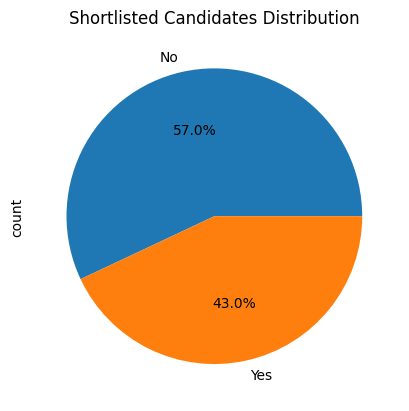

In [11]:
df["Shortlisted"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Shortlisted Candidates Distribution")
plt.show()

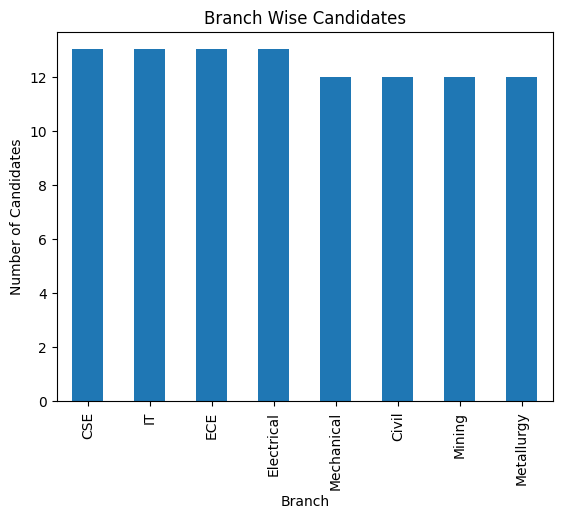

In [12]:
df["Branch"].value_counts().plot(kind="bar")

plt.title("Branch Wise Candidates")
plt.xlabel("Branch")
plt.ylabel("Number of Candidates")

plt.show()

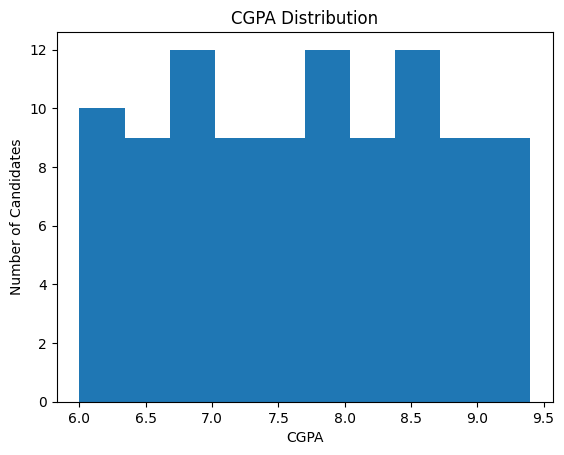

In [13]:
plt.hist(df["CGPA"], bins=10)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Candidates")

plt.show()

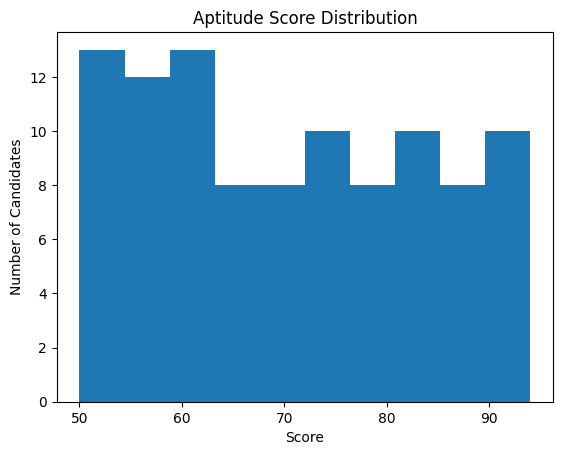

In [14]:
plt.hist(df["Aptitude_Score"], bins=10)

plt.title("Aptitude Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Candidates")

plt.show()

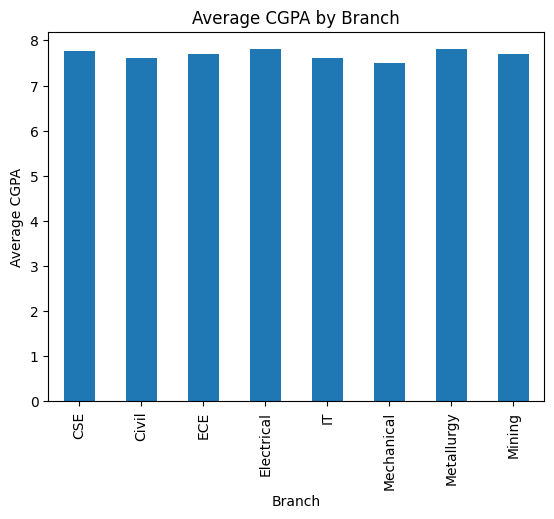

In [15]:
df.groupby("Branch")["CGPA"].mean().plot(kind="bar")

plt.title("Average CGPA by Branch")
plt.xlabel("Branch")
plt.ylabel("Average CGPA")

plt.show()

In [16]:
df = df.drop(["Candidate_ID", "Candidate_Name"], axis=1)

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Hometown,State,College_Name,College_Tier,Degree,Branch,Graduation_Year,CGPA,10th_Percentage,12th_Percentage,Internship,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs,Shortlisted
0,23,1,8,1,0,0,0,0,2024,6.2,67,62,1,2,2,52,50,57,0,0
1,24,0,5,1,1,1,0,4,2025,6.3,68,63,0,3,3,53,51,58,0,0
2,25,1,2,1,5,2,0,2,2026,6.4,69,64,1,4,4,54,52,59,0,0
3,26,0,0,1,4,0,0,3,2024,6.5,70,65,1,5,0,55,53,60,1,0
4,21,1,4,1,7,1,0,5,2025,6.6,71,66,0,0,1,56,54,61,0,0


In [18]:
X = df.drop("Shortlisted", axis=1)

y = df["Shortlisted"]

In [19]:
print(X.shape)
print(y.shape)

(100, 19)
(100,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)

(80, 19)
(20, 19)


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model = RandomForestClassifier(
    random_state=42
)

In [24]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11  0]
 [ 1  8]]


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



In [29]:
print(X.columns)

Index(['Age', 'Gender', 'Hometown', 'State', 'College_Name', 'College_Tier',
       'Degree', 'Branch', 'Graduation_Year', 'CGPA', '10th_Percentage',
       '12th_Percentage', 'Internship', 'Internship_Duration_Months',
       'Certifications_Count', 'Aptitude_Score', 'Technical_Score',
       'Communication_Score', 'Backlogs'],
      dtype='object')


In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                       Feature  Importance
15              Aptitude_Score    0.259054
16             Technical_Score    0.168163
9                         CGPA    0.117795
11             12th_Percentage    0.104874
17         Communication_Score    0.069463
18                    Backlogs    0.067978
14        Certifications_Count    0.064515
10             10th_Percentage    0.034799
2                     Hometown    0.034794
13  Internship_Duration_Months    0.015533


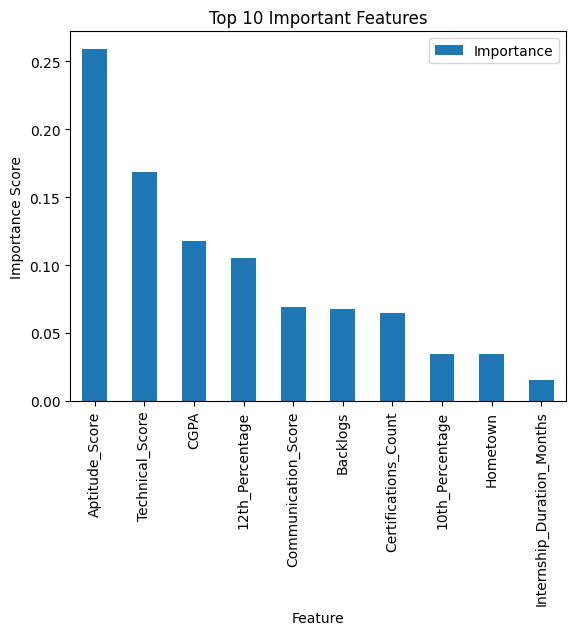

In [31]:
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

In [32]:
import joblib

joblib.dump(model, "random_forest_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [33]:
shortlisted_candidates = df[df["Shortlisted"] == 1]

shortlisted_candidates.head(10)

,Age,Gender,Hometown,State,College_Name,College_Tier,Degree,Branch,Graduation_Year,CGPA,10th_Percentage,12th_Percentage,Internship,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs,Shortlisted
10,21,1,8,1,5,1,0,2,2025,7.2,77,72,0,0,2,62,60,67,0,1
11,22,0,5,1,4,2,0,3,2026,7.3,78,73,1,1,3,63,61,68,0,1
12,23,1,2,1,7,0,0,5,2024,7.4,79,74,1,2,4,64,62,69,0,1
14,25,1,4,1,2,2,0,7,2026,7.6,81,76,1,4,1,66,64,71,0,1
15,26,0,7,0,3,0,0,6,2024,7.7,82,77,1,5,2,67,65,72,0,1
16,21,1,3,0,0,1,0,0,2025,7.8,83,78,0,0,3,68,66,73,0,1
17,22,0,1,1,1,2,0,4,2026,7.9,84,79,1,1,4,69,67,74,0,1
19,24,0,6,3,4,1,0,3,2025,8.1,86,81,0,3,1,71,69,76,0,1
20,25,1,8,1,7,2,0,5,2026,8.2,87,82,1,4,2,72,70,77,0,1
21,26,0,5,1,6,0,0,1,2024,8.3,88,83,1,5,3,73,71,78,0,1


# Conclusion

A Machine Learning based Candidate Shortlisting System was developed for MECON.

The model analyzes candidate information such as:

- CGPA
- Aptitude Score
- Technical Score
- Internship Experience
- Communication Skills

and predicts whether a candidate should be shortlisted for an interview.

This can help recruiters reduce manual screening effort and improve recruitment efficiency.

In [34]:
shortlisted_candidates = df[df["Shortlisted"] == 1]

shortlisted_candidates.head()

,Age,Gender,Hometown,State,College_Name,College_Tier,Degree,Branch,Graduation_Year,CGPA,10th_Percentage,12th_Percentage,Internship,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs,Shortlisted
10,21,1,8,1,5,1,0,2,2025,7.2,77,72,0,0,2,62,60,67,0,1
11,22,0,5,1,4,2,0,3,2026,7.3,78,73,1,1,3,63,61,68,0,1
12,23,1,2,1,7,0,0,5,2024,7.4,79,74,1,2,4,64,62,69,0,1
14,25,1,4,1,2,2,0,7,2026,7.6,81,76,1,4,1,66,64,71,0,1
15,26,0,7,0,3,0,0,6,2024,7.7,82,77,1,5,2,67,65,72,0,1


In [35]:
top_candidates = shortlisted_candidates.sort_values(
    by="Technical_Score",
    ascending=False
)

top_candidates.head(10)

,Age,Gender,Hometown,State,College_Name,College_Tier,Degree,Branch,Graduation_Year,CGPA,10th_Percentage,12th_Percentage,Internship,Internship_Duration_Months,Certifications_Count,Aptitude_Score,Technical_Score,Communication_Score,Backlogs,Shortlisted
42,23,1,2,1,5,0,0,2,2024,6.9,79,69,1,2,4,94,92,59,0,1
41,22,0,5,1,1,2,0,4,2026,6.8,78,68,1,1,3,93,91,58,0,1
40,21,1,8,1,0,1,0,0,2025,6.7,77,67,0,0,2,92,90,57,0,1
39,26,0,6,3,3,0,0,6,2024,6.6,76,66,1,5,1,91,89,56,0,1
87,26,0,1,1,3,0,0,6,2024,7.9,94,79,1,5,4,94,89,64,0,1
86,25,1,3,0,2,2,0,7,2026,7.8,93,78,1,4,3,93,88,63,0,1
85,24,0,7,0,6,1,0,1,2025,7.7,92,77,0,3,2,92,87,62,0,1
84,23,1,4,1,7,0,0,5,2024,7.6,91,76,1,2,1,91,86,61,0,1
82,21,1,2,1,5,1,0,2,2025,7.4,89,74,0,0,4,89,84,59,0,1
81,26,0,5,1,1,0,0,4,2024,7.3,88,73,1,5,3,88,83,58,0,1


In [37]:
top_candidates[
    [
        "CGPA",
        "Aptitude_Score",
        "Technical_Score"
    ]
].head(10)

,CGPA,Aptitude_Score,Technical_Score
42,6.9,94,92
41,6.8,93,91
40,6.7,92,90
39,6.6,91,89
87,7.9,94,89
86,7.8,93,88
85,7.7,92,87
84,7.6,91,86
82,7.4,89,84
81,7.3,88,83


In [38]:
top_candidates.head(10).to_excel(
    "Top_10_Candidates.xlsx",
    index=False
)

print("Excel File Created Successfully")

Excel File Created Successfully


In [39]:
print("Total Candidates:", len(df))
print("Shortlisted:", len(shortlisted_candidates))
print("Rejected:", len(df) - len(shortlisted_candidates))

Total Candidates: 100
Shortlisted: 43
Rejected: 57


In [40]:
selection_rate = (
    len(shortlisted_candidates) /
    len(df)
) * 100

print("Selection Rate:", round(selection_rate, 2), "%")

Selection Rate: 43.0 %
